In [9]:
import numpy as np
import h5py as h5
from astropy.io import fits
import matplotlib.pyplot as plt
%matplotlib inline



In [4]:
ldir = '/mnt/ceph/users/spandey/xdesi/des/clusters'
fname_cluster = ldir + '/des_run_redmapper_v0.9.0_lgt05_vl05_catalog.fit'
fname_rand = ldir + '/y3_gold_2.2.1_wide_sofcol_run2_redmapper_v6.4.22+2_randcat_z0.10-0.95_lgt005_vl02.fit'




In [8]:
df_cluster = fits.open(fname_cluster)
# df_cluster[1].header
ra_c = df_cluster[1].data['ra']
dec_c = df_cluster[1].data['dec']
z_c = df_cluster[1].data['z']
lambda_c = df_cluster[1].data['lambda']




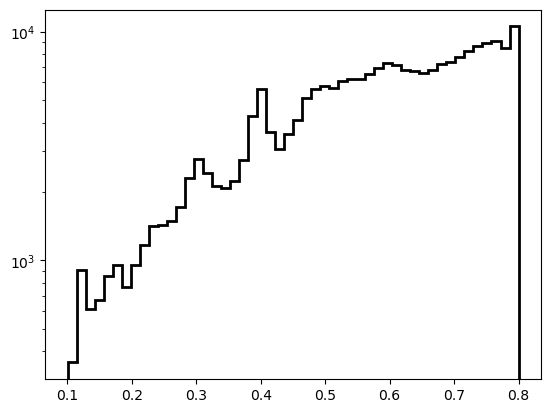

In [16]:
plt.figure()
# _ = plt.hist(lambda_c, bins=50, histtype='step', color='k', lw=2)
_ = plt.hist(z_c, bins=50, histtype='step', color='k', lw=2)
plt.yscale('log')


In [17]:
indsel = np.where((lambda_c > 20) & (z_c > 0.5) & (z_c < 0.8))[0]
print('Number of clusters selected: ', len(indsel))
ra_c_sel, dec_c_sel, z_c_sel, lambda_c_sel = ra_c[indsel], dec_c[indsel], z_c[indsel], lambda_c[indsel]



Number of clusters selected:  9245


In [21]:
df_rand = fits.open(fname_rand)
# df_rand[1].header
ra_rand = df_rand[1].data['RA']
dec_rand = df_rand[1].data['DEC']
z_rand = df_rand[1].data['ZTRUE']

# print(len(ra_rand), len(dec_rand), len(z_rand))
indsel_rand = np.where((z_rand > 0.5) & (z_rand < 0.8))[0]
print('Number of randoms selected: ', len(indsel_rand))
ra_rand_sel, dec_rand_sel, z_rand_sel = ra_rand[indsel_rand], dec_rand[indsel_rand], z_rand[indsel_rand]

indsel = np.random.choice(len(ra_rand_sel), size=50*len(ra_c_sel), replace=False)
print('Number of randoms selected after random sampling: ', len(indsel))
ra_rand_sel, dec_rand_sel, z_rand_sel = ra_rand_sel[indsel], dec_rand_sel[indsel], z_rand_sel[indsel]


Number of randoms selected:  22964658
Number of randoms selected after random sampling:  462250


Reading mask...
Opening y-map and mask


TypeError: k is not defined.

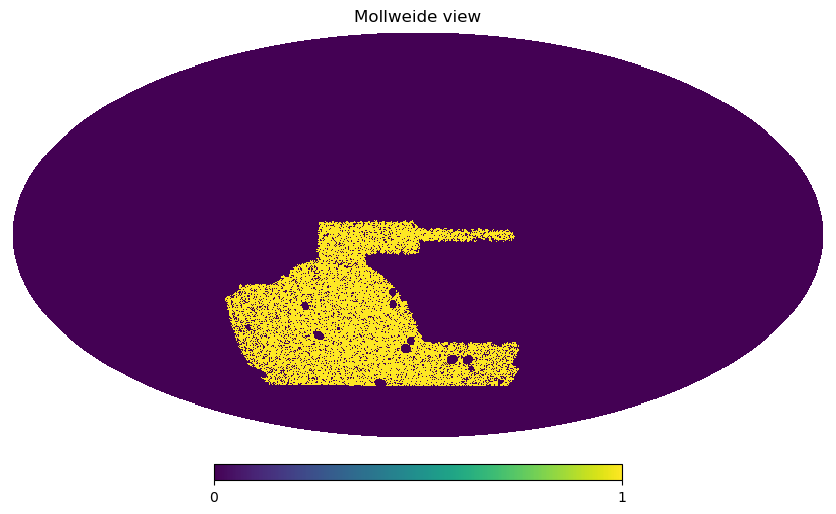

In [ ]:
import healpy as hp
import dill
from pixell import enmap
import treecorr
import gc
import sys, os

def ang2eq(theta, phi):
    ra = phi * 180. / np.pi
    dec = 90. - theta * 180. / np.pi
    return ra, dec

def eq2ang(ra, dec):
    phi = ra * np.pi / 180.
    theta = (np.pi / 2.) - dec * (np.pi / 180.)
    return theta, phi

# Constants and configuration
NSIDE = 4096
MASK_PATH = '/mnt/ceph/users/spandey/xdesi/act/tsz/cib_cibdBeta/mask_updated_ACTDR6xDESY3.fits'
YMAP_DIR = '/mnt/ceph/users/spandey/xdesi/act/tsz/cib_cibdBeta/'
YMAP_PATH = YMAP_DIR + 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy.fits'
NJK = 250
JK_OBJ_FILENAME = f'/mnt/ceph/users/spandey/xdesi/act/tsz/cib_cibdBeta/jkobj_DES_cluster_njk_{NJK}_v27Mar23.pk'
NUM_CORES = 128
RAD2DEG = 180. / np.pi

# TreeCorr configuration
treecorr_config = {
    'nbins': 20,
    'min_sep': 2.5,
    'max_sep': 250.,
    'sep_units': 'arcmin',
    'bin_slop': 0.0,
    'num_threads': NUM_CORES,
    'var_method': 'jackknife',
    'verbose': 0
}

# Read mask and get unmasked pixels
print("Reading mask...")
mask_f = hp.read_map(MASK_PATH)
hp.mollview(mask_f)
ind_unmasked = np.where(mask_f > 0.9)[0]
del mask_f
gc.collect()



# Read y-map
print('Opening y-map and mask')
imapy = enmap.read_map(YMAP_PATH)
decs, ras = imapy.posmap()
ra_y = np.array(RAD2DEG * ras.flatten())
dec_y = np.array(RAD2DEG * decs.flatten())
ymap_truth = np.array(imapy.flatten())

# Filter by mask
theta_datapoint_all, phi_datapoint_all = eq2ang(ra_y, dec_y)
ind_datapoints = hp.ang2pix(NSIDE, theta_datapoint_all, phi_datapoint_all)
selection_f = np.where(np.in1d(ind_datapoints, ind_unmasked))[0]

del theta_datapoint_all, phi_datapoint_all, ind_datapoints
gc.collect()

# Process each redshift bin
    
jk_obj_path = JK_OBJ_FILENAME

# Create catalogs for correlation
cat_y = treecorr.Catalog(
    ra=ra_y[selection_f], 
    dec=dec_y[selection_f], 
    ra_units='deg', 
    dec_units='deg',
    k=ymap_truth[selection_f], 
    patch_centers=jk_obj_path if os.path.isfile(jk_obj_path) else None,
    npatch=NJK if not os.path.isfile(jk_obj_path) else None
)

# Save jackknife centers if needed
if not os.path.isfile(jk_obj_path):
    cat_y.write_patch_centers(jk_obj_path)
    
cat_c = treecorr.Catalog(
    ra=ra_c_sel, 
    dec=dec_c_sel, 
    ra_units='deg', 
    dec_units='deg', 
    patch_centers=jk_obj_path
) 

cat_r = treecorr.Catalog(
    ra=ra_rand_sel, 
    dec=dec_rand_sel, 
    ra_units='deg', 
    dec_units='deg', 
    patch_centers=jk_obj_path
)

gc.collect()




In [25]:
# Calculate NK correlation
yc = treecorr.NKCorrelation(**treecorr_config)

yc.process(cat_c, cat_y, num_threads=NUM_CORES)
print('Computing NK correlation')

yr = treecorr.NKCorrelation(**treecorr_config)

yr.process(cat_r, cat_y, num_threads=NUM_CORES)
print('Computing NK covariance')

xi_kg = yc.calculateXi(rk=yr)
r_kg = np.exp(yc.meanlogr)

cov_kg = yc.estimate_cov('jackknife')

# Extract results

print(f"r_kg: {r_kg}")
print(f"xi_kg: {xi_kg}")
print(f"Diagonal errors: {np.sqrt(np.diag(cov_kg))}")

# Save results
save_data = {
    # 'kg': kg,
    'xi_kg': xi_kg,
    'r_kg': r_kg, 
    'cov_dy': cov_kg, 
    'njk': NJK
}








Computing NK correlation
Computing NK covariance
r_kg: [  2.82965119   3.56208967   4.48379869   5.64528042   7.10770896
   8.94787224  11.26427488  14.18138466  17.8534932   22.47552727
  28.29553901  35.62274647  44.84505066  56.4558489   71.07389065
  89.4729306  112.64354139 141.79877967 178.51719911 224.74116894]
xi_kg: (array([ 6.27199260e-07,  4.13113102e-07,  2.26694205e-07,  2.06918165e-07,
        1.27911653e-07,  1.48347502e-07,  1.16732755e-07,  1.03382985e-07,
        7.58138534e-08,  6.80900728e-08,  5.05294527e-08,  3.97255329e-08,
        2.35017440e-08,  1.40533055e-08,  1.74385011e-08,  1.47498860e-08,
        1.20186614e-08,  2.57095245e-10, -3.87700758e-09,  4.75231081e-09]), array([4.47995022e-15, 3.44451975e-15, 3.02525269e-15, 1.96084736e-15,
       1.55703738e-15, 1.20535774e-15, 1.08126970e-15, 1.13309261e-15,
       1.08613999e-15, 9.42924230e-16, 8.45385845e-16, 8.22206048e-16,
       8.73017191e-16, 8.24382840e-16, 8.18161440e-16, 8.00206455e-16,
       8.38

Text(0, 0.5, '$\\xi_{cy}$')

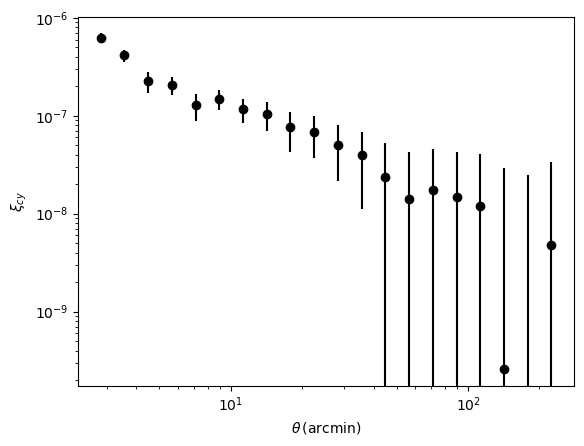

In [ ]:
plt.figure()
plt.errorbar(r_kg, xi_kg[0], yerr=np.sqrt(np.diag(cov_kg)), fmt='o', color='k', label='Data')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta \, (\mathrm{arcmin})$')
plt.ylabel(r'$\xi_{cy}$')



In [ ]:
# def ang2eq(theta, phi):
#     ra = phi * 180. / np.pi
#     dec = 90. - theta * 180. / np.pi
#     return ra, dec

# def eq2ang(ra, dec):
#     phi = ra * np.pi / 180.
#     theta = (np.pi / 2.) - dec * (np.pi / 180.)
#     return theta, phi

# # Constants and configuration
# NSIDE = 4096
# MASK_PATH = '/global/cfs/cdirs/des/data_actxdes/mask_updated_ACTDR6xDESY3.fits'
# YMAP_DIR = '/global/cfs/cdirs/act/data/synced_maps/ILC_MAPS/20230606/'
# SAVE_DIR = '/global/cfs/cdirs/lsst/www/shivamp/cosmosis-standard-library/ACTxDESY3/src/run_measurements/results_nzfix_Feb25/'
# NJK = 250
# JK_OBJ_FILENAME = f'jkobj_DES_njk_{NJK}_v27Mar23.pk'
# NUM_CORES = 256
# RAD2DEG = 180. / np.pi

# # TreeCorr configuration
# treecorr_config = {
#     'nbins': 20,
#     'min_sep': 2.5,
#     'max_sep': 250.,
#     'sep_units': 'arcmin',
#     'bin_slop': 0.0,
#     'num_threads': NUM_CORES,
#     'var_method': 'jackknife',
#     'verbose': 0
# }

# # List of deprojections
# deproj_list = ['cib_1p7_dBeta', 'None', 'cib_1p4', 'cib_1p7', 'cib_2p0', 'cib_1p4_dBeta', 'cib_2p0_dBeta']

# # File mapping for different deprojections
# deproj_to_file = {
#     'None': 'ilc_SZ_yy.fits',
#     'cib_1p0': 'ilc_SZ_deproj_cib_1.0_10.7_yy.fits',
#     'cib_1p2': 'ilc_SZ_deproj_cib_1.2_10.7_yy.fits',
#     'cib_1p4': 'ilc_SZ_deproj_cib_1.4_10.7_yy.fits',
#     'cib_1p6': 'ilc_SZ_deproj_cib_1.6_10.7_yy.fits',
#     'cib_1p8': 'ilc_SZ_deproj_cib_1.8_10.7_yy.fits',
#     'cib_2p0': 'ilc_SZ_deproj_cib_2.0_10.7_yy.fits',
#     'cib_1p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.0_10.7_yy.fits',
#     'cib_1p2_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.2_10.7_yy.fits',
#     'cib_1p4_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.4_10.7_yy.fits',
#     'cib_1p6_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy.fits',
#     'cib_1p7_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy.fits',
#     'cib_1p8_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.8_10.7_yy.fits',
#     'cib_2p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_2.0_10.7_yy.fits'
# }

# # Read mask and get unmasked pixels
# print("Reading mask...")
# mask_f = hp.read_map(MASK_PATH)
# hp.mollview(mask_f)
# ind_unmasked = np.where(mask_f > 0.9)[0]
# del mask_f
# gc.collect()

# # Process each deprojection
# for deproj in deproj_list:
#     print(f'Processing {deproj}')
    
#     # Get y-map file path
#     y_file = os.path.join(YMAP_DIR, deproj_to_file.get(deproj, ''))
#     if not os.path.exists(y_file):
#         print(f"File not found: {y_file}")
#         continue
    
#     # Read y-map
#     print('Opening y-map and mask')
#     imapy = enmap.read_map(y_file)
#     decs, ras = imapy.posmap()
#     ra_y = np.array(RAD2DEG * ras.flatten())
#     dec_y = np.array(RAD2DEG * decs.flatten())
#     ymap_truth = np.array(imapy.flatten())
    
#     # Filter by mask
#     theta_datapoint_all, phi_datapoint_all = eq2ang(ra_y, dec_y)
#     ind_datapoints = hp.ang2pix(NSIDE, theta_datapoint_all, phi_datapoint_all)
#     selection_f = np.where(np.in1d(ind_datapoints, ind_unmasked))[0]
    
#     del theta_datapoint_all, phi_datapoint_all, ind_datapoints
#     gc.collect()
    
#     # Process each redshift bin
#     for jb in range(4):
#         file_suffix = f'zbin_{jb}_njk_{NJK}'
#         save_fname = os.path.join(
#             SAVE_DIR, 
#             f'kg_act_deprojects_{deproj}_vnew_wbeam_pixell_{file_suffix}_healpix{NSIDE}_theta_2p5_250_vFeb25.pk'
#         )
        
#         if os.path.isfile(save_fname):
#             print(f'Skipping bin {jb+1}, file already exists')
#             continue
            
#         print(f'Processing bin: {jb+1}')
#         jk_obj_path = os.path.join(SAVE_DIR, JK_OBJ_FILENAME)
        
#         # Create catalogs for correlation
#         cat_b = treecorr.Catalog(
#             ra=ra_y[selection_f], 
#             dec=dec_y[selection_f], 
#             ra_units='deg', 
#             dec_units='deg',
#             k=ymap_truth[selection_f], 
#             patch_centers=jk_obj_path if os.path.isfile(jk_obj_path) else None,
#             npatch=NJK if not os.path.isfile(jk_obj_path) else None
#         )
        
#         # Save jackknife centers if needed
#         if not os.path.isfile(jk_obj_path):
#             cat_b.write_patch_centers(jk_obj_path)
            
#         cat_a = treecorr.Catalog(
#             ra=cat_DES[jb][2], 
#             dec=cat_DES[jb][3], 
#             g1=cat_DES[jb][0], 
#             g2=cat_DES[jb][1],
#             w=cat_DES[jb][5],
#             ra_units='deg', 
#             dec_units='deg', 
#             patch_centers=jk_obj_path
#         ) 
        
#         gc.collect()
        
#         # Calculate KG correlation
#         kg = treecorr.KGCorrelation(**treecorr_config)
#         print('Computing KG correlation')
#         kg.process(cat_b, cat_a, num_threads=NUM_CORES)
#         print('Computing KG covariance')
#         cov_kg = kg.estimate_cov('jackknife')
        
#         # Extract results
#         xi_kg = kg.xi
#         r_kg = np.exp(kg.meanlogr)
        
#         print(f"r_kg: {r_kg}")
#         print(f"xi_kg: {xi_kg}")
#         print(f"Diagonal errors: {np.sqrt(np.diag(cov_kg))}")
        
#         # Save results
#         save_data = {
#             # 'kg': kg,
#             'xi_kg': xi_kg,
#             'r_kg': r_kg, 
#             'cov_dy': cov_kg, 
#             'njk': NJK
#         }
        
#         dill.dump(save_data, open(save_fname, 'wb'))
#         print(f"Saved results to {save_fname}")





